<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 3: Transformers
### **Sesión 2/3: Redes recurrentes y embedding**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [Procesamiento de secuencias](#secuencias)
- [Redes recurrentes](#rnn)
- [Embedding](#embedding)
- [Ejercicios](#ejercicios)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine learning)
- [Matplotlib](https://pypi.org/project/matplotlib/) (visualización de datos)
- [Pandas](https://pypi.org/project/seaborn/) (manipulación de datos tabulados)

### Procesamiento de secuencias
<a class='anchor' id='secuencias'></a>

Una de las limitaciones de las aproximaciones utilizadas en la Sesión 1 de esta práctica es que tratan los fragmentos de texto simplemente como un conjunto de tokens (*bag-of-words*) y no como secuencias, siendo por tanto insensibles al orden los tokens en un texto. En la mayoría de los casos la relación de un token con sus vecinos condiciona su semántica. La información adicional proporcionada por la relación de una palabra (token) con sus vecinas permite a estos modelos obtener mejores resultados cuando las condiciones son las adecuadas.

### Redes recurrentes
<a class='anchor' id='rnn'></a>

Las redes neuronales recurrentes (RNNs) se desarrollaron para procesar series temporales en la que una magnitud varía en función del tiempo. El texto se puede transformar en una secuencia temporal codificando cada token y asignándole a su posición en la secuencia un valor temporal. El problema de las primeras RNNs era el desvanecimiento de gradiente que aparecía cuando se querían procesar secuencias largas. Para solventar este problema surgió la arquitectura *long short-term memory* (LSTM) que se basa en células de memoria que pueden retener información durante periodos arbitrarios. Además, en nuestro problema en concreto necesitamos procesar las secuencias en las dos posibles direcciones, ya que no podemos asumir que un AA en un páptido solo dependa de los AAs anteriores, también podría venir influenciado por los AAs posteriores. El esquema de la red LSTM bidireccional que vamos a construir es el siguiente:

<img src="./figs/bi_lstm.png" width="400">

Keras dispone de dos classes que permitirán construir fácilmente esta red RNN, la clase [LSTM](https://keras.io/api/layers/recurrent_layers/lstm/) que construye una capa de celular LSTM y la clase [Bidirectional](https://keras.io/api/layers/recurrent_layers/bidirectional/) que pasa las secuencias en los dos direcciones para finalmente fusionar la salida.

### Embedding
<a class='anchor' id='embedding'></a>

Cuando se realiza una codificación directa sin analizar los datos como one-hot, que a cada token le asigna un vector con tantas dimensiones como palabras tiene el lenguaje con todos los valores a 0 excepto un 1 en el índice de la palabra correspondiente, en realidad se está asumiendo que todos los tokens son independientes los unos de los otros. En one-hot los vectores que se generan son ortonormales entre sí. En general las palabras (tokens) de un lenguaje forman un espacio estructurado: comparten información entre ellas. Las palabras "palabra" y "token" son intercambiables en la mayoría de los casos de este documento, luego un vector que represente a "palabra" no debería ser ortonormal del que representa a "token", estos vectores deberían ser muy similares. Con *embedding* nos referimos a obtener una representación que haga precisamente esto: mapear las palabras de un lenguaje en un espacio geométrico estructurado. La clase [Embedding](https://keras.io/api/layers/core_layers/embedding/) del paquete Keras permite crear una capa para hacer un embedding de los datos de entrada a una red de forma sencilla.

Mientras que los vectores obtenidos por una codificación one-hot son dispersos (muchos bits para representar poca información), binarios y tienen una dimensión que depende del tamaño del vocabulario de un lenguaje. El embedding permite generar vectores densos, con una dimensionalidad arbitraria y que se representan una estructura aprendida de los datos. Palabras similares aparecen próximas en el espacio embebido, es más, aparecerán direcciones con un significado semántico específico. Por ejemplo, en la gráfica de abajo se muestra se muestran cuatro palabras embebidas en un plano 2D: "gato", "perro", "lobo" y "tigre". En este espacio relaciones semánticas se han codificado en transformaciones geométricas. El mismo vector que nos permite movernos de "gato" a "tigre", también nos llevaría de "perro" a "lobo", luego este vector se podría interpretar como la transformación: de animal doméstico a salvaje. De manera similar, el vector que nos lleva de "perro" a "gato" o de "lobo" a "tigre" se podría interpretar como la transformación: de canino a felino.

<img src="./figs/embedding.png" width="400">

En la práctica los lenguajes suelen ser tan complejos que los embeddings que los representar suelen tener muchas dimensiones. Para analizar visualmente estos espacios se requiere de técnicas de reducción de la dimensionalidad, dónde PCA (Principal Components Analysis) sea quizás la más conocida. Estas técnicas permiten proyectar un espacio de muchas dimensiones en un plano 2D minimizando la información pérdida y facilianado su análisis mediante inspección visual. El paquete *scikit-learn* contiene la clase [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) con una implementación del algoritmo PCA.

### Ejercicios
<a class='anchor' id='ejercicios'></a>

**E1:** Codifica el dataset de la Sesión 1 utilizando esta vez una codificación de tipo *integer*.

**E2:** Construye un modelo LSTM bidireccional con 50 células LSTM, entrénalo empleando el resultado de E1 y evalúa la precisión del modelo entrenado. Para el entrenamiento utiliza la aproximación empleada para los ejercicios de la Sesión 1.

**E3:** Repite el ejercicio anterior, pero utilizando una codificación *one-hot*. ¿Qué ventaja ofrece la codificación *one-hot* sobre *integer*? ¿Se podría utilizar la codificación *one-hot* para procesar lenguaje natural? ¿por qué?

**E4:** Repite el ejercicio anterior, pero utilizando *embedding* de 16 dimensiones sobre la codificación *integer*. ¿Mejoran los resultados? ¿por qué? ¿Ayuda activar la opción *mask_zero* de la capa de embedding? ¿por qué?

**E5:** Realiza varias repeticiones del entrenamiento de los modelos en los E2-3. ¿Obtienes siempre los mismos resultados? ¿por qué? ¿qué modelo presenta un comportamiento más estable?

**E6:** Representa en un plano 2D los diferentes AAs sobre espacio generados por el embedding. ¿Pon un ejemplo de dos AAs con una funcionalidad muy similar? ¿qué AAs parecen tener un comportamiento diferente al resto?

In [1]:
# ===================================================
# Importaciones y fijar semilla para reproducibilidad
# ===================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional, Embedding, Input
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

seed = 42

np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

I0000 00:00:1774438043.883901  116660 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774438043.913728  116660 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774438044.690562  116660 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Código heredado Sesión 1
# === Carga, fusión y análisis ===
non_amp_path = "data/in/non_amp_ampep_cdhit90.csv"
amp_path = "data/in/veltri_dramp_cdhit_90.csv"

df_non = pd.read_csv(non_amp_path, index_col=0)
df_amp = pd.read_csv(amp_path, index_col=0)

df = pd.concat([df_non, df_amp], axis=0, ignore_index=True)

# Normalizar secuencias para evitar duplicados por mayúsculas/minúsculas
df["aa_seq"] = df["aa_seq"].astype(str).str.strip().str.upper()

# Calcular de nuevo la longitud por seguridad
df["aa_len"] = df["aa_seq"].str.len()

df = df[["aa_seq", "aa_len", "AMP"]].copy()
df["AMP"] = df["AMP"].astype(int)

peptides = df["aa_seq"].tolist()
labels = df["AMP"].tolist()

max_len = max(len(s) for s in peptides)
longest_seq = max(peptides, key=len)
vocab = sorted(set("".join(peptides)))
n_aas = len(vocab)

# Split estratificado 80/20 ===
X = np.array(peptides)
y = np.array(labels)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

In [3]:
# === E1: Codificación Integer ===
max_len = max(len(s) for s in X_train_text)  # Extraído de la sesión 1

vectorizer_int = tf.keras.layers.TextVectorization(
    standardize=None,
    split="character",
    output_mode="int",
    output_sequence_length=max_len,
)

vectorizer_int.adapt(X_train_text)

X_train_int = vectorizer_int(tf.constant(X_train_text)).numpy()
X_test_int = vectorizer_int(tf.constant(X_test_text)).numpy()
vocab_int = vectorizer_int.get_vocabulary()

print("=== E1 ===")
print(f"Tamaño vocabulario: {len(vocab_int)}")
print(f"Forma train integer: {X_train_int.shape}")

W0000 00:00:1774438045.275050  116660 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774438045.289674  116660 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774438045.408662  116660 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1774438045.409974  116660 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4792 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


=== E1 ===
Tamaño vocabulario: 26
Forma train integer: (3178, 101)


In [4]:
# === E2: LSTM Bidireccional con codificación Integer ===

# LSTM requiere entrada 3D: (batch_size, timesteps, features)
# Como la feature es un solo número entero, expandimos dimensiones.
X_train_int_3d = np.expand_dims(X_train_int, -1)
X_test_int_3d = np.expand_dims(X_test_int, -1)

model_int = Sequential(
    [
        Input(shape=(max_len, 1)),
        Bidirectional(LSTM(50)),
        Dense(1, activation="sigmoid"),
    ],
    name="LSTM_Integer",
)

model_int.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

print("=== E2: Entrenamiento ===")
history_int = model_int.fit(
    X_train_int_3d,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1,
)

loss_int, acc_int = model_int.evaluate(X_test_int_3d, y_test, verbose=0)
print(f"Test Accuracy LSTM Integer: {acc_int:.4f}")
print(f"Test Loss LSTM Integer: {loss_int:.4f}")

=== E2: Entrenamiento ===
Epoch 1/10


I0000 00:00:1774438047.375430  116796 cuda_dnn.cc:461] Loaded cuDNN version 91801


80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5944 - loss: 0.6712 - val_accuracy: 0.6431 - val_loss: 0.6400
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6353 - loss: 0.6436 - val_accuracy: 0.6462 - val_loss: 0.6298
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6412 - loss: 0.6383 - val_accuracy: 0.6651 - val_loss: 0.6217
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6491 - loss: 0.6263 - val_accuracy: 0.6635 - val_loss: 0.6151
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6577 - loss: 0.6144 - val_accuracy: 0.6777 - val_loss: 0.6052
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6825 - loss: 0.5993 - val_accuracy: 0.6934 - val_loss: 0.5910
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6924 - loss: 0.5871 - val_accuracy: 0.6903 - val_loss: 0.5864
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6979 - loss: 0.5803 - val_accuracy: 0.6808 - val_loss: 0.5848
Ep

In [5]:
# === E3: LSTM Bidireccional con One-Hot ===
vocab_size = len(vocab_int)

X_train_oh = tf.one_hot(X_train_int, depth=vocab_size).numpy()
X_test_oh = tf.one_hot(X_test_int, depth=vocab_size).numpy()

model_oh = Sequential(
    [
        Input(shape=(max_len, vocab_size)),
        Bidirectional(LSTM(50)),
        Dense(1, activation="sigmoid"),
    ],
    name="LSTM_OneHot",
)

model_oh.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

print("=== E3: Entrenamiento ===")
history_oh = model_oh.fit(
    X_train_oh,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1,
)

loss_oh, acc_oh = model_oh.evaluate(X_test_oh, y_test, verbose=0)
print(f"Test Accuracy LSTM One-Hot: {acc_oh:.4f}")
print(f"Test Loss LSTM One-Hot: {loss_oh:.4f}")

=== E3: Entrenamiento ===
Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6015 - loss: 0.6619 - val_accuracy: 0.7704 - val_loss: 0.5827
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7541 - loss: 0.5571 - val_accuracy: 0.7846 - val_loss: 0.5152
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7785 - loss: 0.4940 - val_accuracy: 0.7893 - val_loss: 0.4747
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7946 - loss: 0.4678 - val_accuracy: 0.7956 - val_loss: 0.4513
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7970 - loss: 0.4469 - val_accuracy: 0.7940 - val_loss: 0.4384
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8116 - loss: 0.4257 - val_accuracy: 0.8066 - val_loss: 0.4324
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8155 - loss: 0.4109 - val_accuracy: 0.8176 - val_loss: 0.4273
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8151 - loss: 0.4108 - val_a

**Respuestas E3:**
- *¿Qué ventaja ofrece la codificación *one-hot* sobre *integer*?*
  
  La codificación integer le da falsamente un orden numérico y magnitud a categórias nominales (los AAs), por ejemplo pensar que la "Z" vale más que la "A". One-Hot elimina esa jerarquía asignando vectores ortonormales equidistantes para cada token.

- *¿Se podría utilizar la codificación *one-hot* para procesar lenguaje natural? ¿Por qué?*

   Sí, pero es muy poco práctico. El LN tiene vocabularios inmensos (cientos de miles de palabras), lo que daría lugar a matrices one-hot gigantes, dispersas y altamente ineficientes en memoria.

In [6]:
# === E4: LSTM Bidireccional con Embedding ===

model_emb = Sequential(
    [
        Input(shape=(max_len,)),
        Embedding(input_dim=vocab_size, output_dim=16, mask_zero=True),
        Bidirectional(LSTM(50)),
        Dense(1, activation="sigmoid"),
    ],
    name="LSTM_Embedding",
)

model_emb.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

print("=== E4: Entrenamiento ===")
history_emb = model_emb.fit(
    X_train_int,
    y_train,  # Usamos input integer que el Embedding mapeará a densos
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1,
)

loss_emb, acc_emb = model_emb.evaluate(X_test_int, y_test, verbose=0)
print(f"Test Accuracy LSTM Embedding: {acc_emb:.4f}")
print(f"Test Loss LSTM Embedding: {loss_emb:.4f}")


=== E4: Entrenamiento ===
Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6377 - loss: 0.6308 - val_accuracy: 0.7626 - val_loss: 0.5335
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7840 - loss: 0.4989 - val_accuracy: 0.7846 - val_loss: 0.4878
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7974 - loss: 0.4597 - val_accuracy: 0.7925 - val_loss: 0.4658
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8033 - loss: 0.4386 - val_accuracy: 0.7956 - val_loss: 0.4545
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8049 - loss: 0.4244 - val_accuracy: 0.8019 - val_loss: 0.4456
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8175 - loss: 0.4094 - val_accuracy: 0.8035 - val_loss: 0.4385
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8222 - loss: 0.4018 - val_accuracy: 0.8035 - val_loss: 0.4322
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8245 - loss: 0.3936 - val_a

**Respuestas E4:**

- *¿Obtienes siempre los mismos resultados? ¿por qué?*
- *¿Qué modelo presenta un comportamiento más estable?*

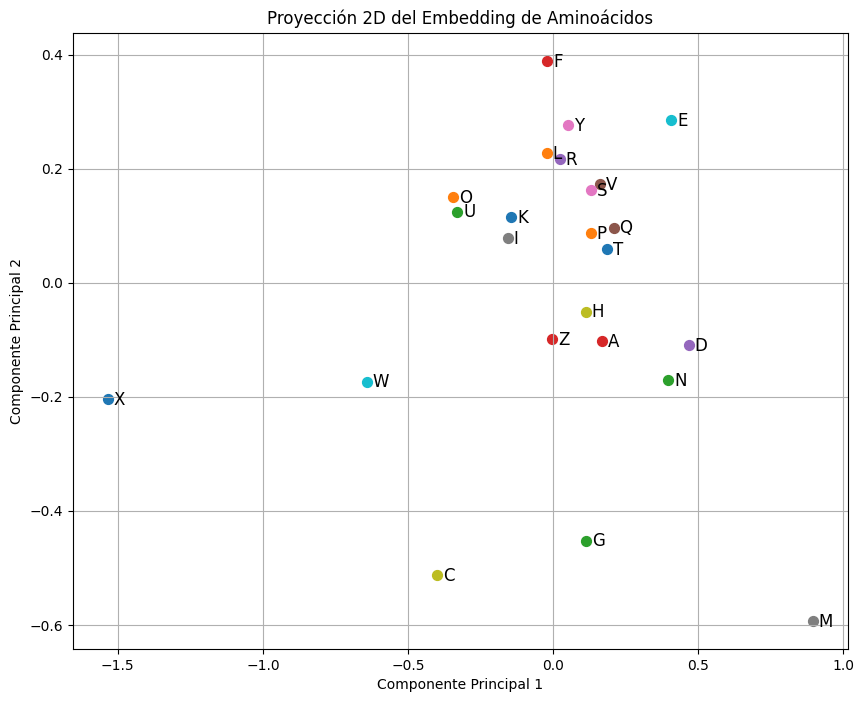

In [14]:
# === E6: Representación 2D del Embedding con PCA ===
from sklearn.decomposition import PCA

# Capa 0 es el Input, Capa 1 es el Embedding (asumiendo model_emb)
# Obtenemos la matriz de pesos: tamaño (vocab_size, 16)
embedding_weights = model_emb.layers[0].get_weights()[0]

# Usamos PCA para reducir de 16D a 2D
pca = PCA(n_components=2)
embedding_2d = pca.fit_transform(embedding_weights)

plt.figure(figsize=(10, 8))
# Ignoramos el token 0 que suele ser el PAD y/o el UNK
for i, token in enumerate(vocab_int):
    if token == "" or token == "[UNK]":
        continue
    x, y = embedding_2d[i, 0], embedding_2d[i, 1]
    plt.scatter(x, y, s=50)
    plt.annotate(token, (x + 0.02, y - 0.01), fontsize=12)

plt.title("Proyección 2D del Embedding de Aminoácidos")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()